# US Accidents (2016-2023): Exploratory Analysis & Hypothesis Testing

Data Analyst/BI portfolio project. See `vault/Data-Dictionary.md` for column definitions and `vault/Methodology-Log.md` for how this data was processed.

In [1]:
"""Setup: load the pre-aggregated Parquet files produced by
scripts/build_aggregates.py. This notebook never touches the raw
3GB CSV directly.
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from us_accidents.stats_tests import (
    anova_severity_by_hour,
    chi_square_severity_by_weather,
    logistic_regression_high_severity,
)

by_state = pd.read_parquet("../data/processed/by_state.parquet")
by_weather = pd.read_parquet("../data/processed/by_weather.parquet")
by_hour = pd.read_parquet("../data/processed/by_hour.parquet")
sample = pd.read_parquet("../data/processed/sample_for_stats.parquet")

sns.set_theme(style="whitegrid")

## Descriptive EDA

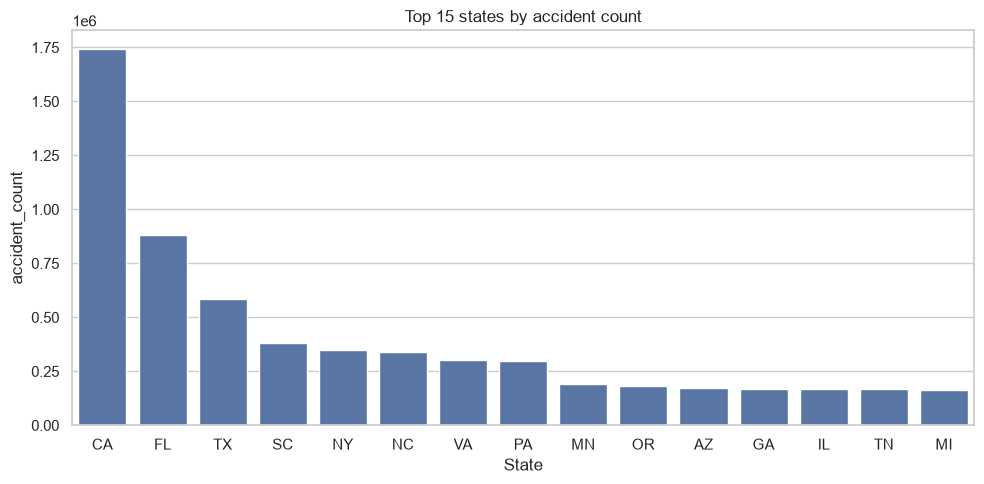

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
top_states = by_state.head(15)
sns.barplot(data=top_states, x="State", y="accident_count", ax=ax)
ax.set_title("Top 15 states by accident count")
plt.tight_layout()
plt.savefig("../report/fig_top_states.png", dpi=150)
plt.show()

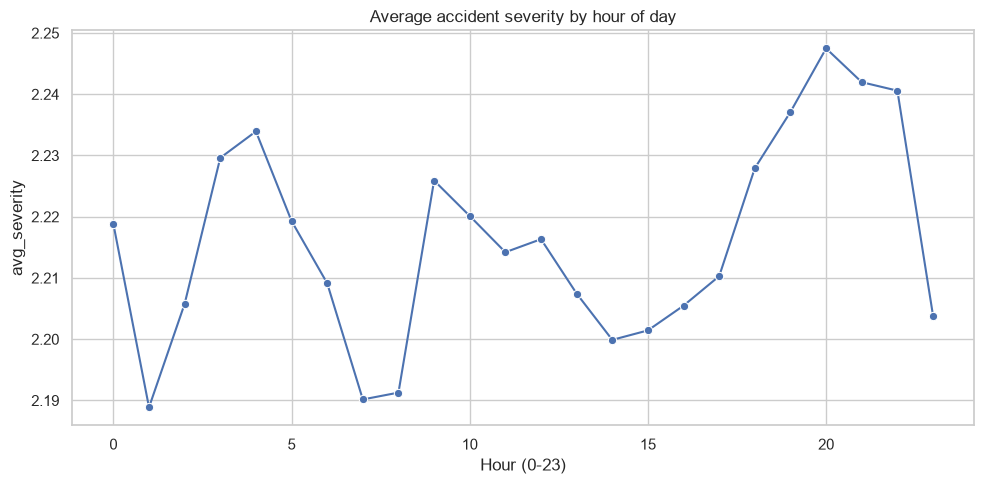

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=by_hour, x="hour", y="avg_severity", marker="o", ax=ax)
ax.set_title("Average accident severity by hour of day")
ax.set_xlabel("Hour (0-23)")
plt.tight_layout()
plt.savefig("../report/fig_severity_by_hour.png", dpi=150)
plt.show()

## H1: Severity vs. weather condition

In [4]:
"""H1: Accident severity is associated with weather condition."""
chi2_result = chi_square_severity_by_weather(sample)
print(
    f"Chi-square = {chi2_result['statistic']:.2f}, "
    f"p = {chi2_result['p_value']:.4g}, "
    f"df = {chi2_result['dof']}"
)
chi2_finding = (
    f"Severity IS significantly associated with weather condition "
    f"(chi-square = {chi2_result['statistic']:.2f}, p = {chi2_result['p_value']:.4g})."
    if chi2_result["significant"]
    else
    f"No significant association found between severity and weather "
    f"condition (chi-square = {chi2_result['statistic']:.2f}, p = {chi2_result['p_value']:.4g})."
)
print(chi2_finding)

Chi-square = 9674.69, p = 0, df = 276
Severity IS significantly associated with weather condition (chi-square = 9674.69, p = 0).


## H2: Severity vs. hour of day

In [5]:
"""H2: Mean accident severity differs by hour of day."""
anova_result = anova_severity_by_hour(sample)
anova_finding = (
    f"Mean severity DOES differ significantly by hour of day "
    f"(F = {anova_result['statistic']:.2f}, p = {anova_result['p_value']:.4g})."
    if anova_result["significant"]
    else
    f"No significant difference in mean severity across hours of day "
    f"(F = {anova_result['statistic']:.2f}, p = {anova_result['p_value']:.4g})."
)
print(anova_finding)

Mean severity DOES differ significantly by hour of day (F = 9.83, p = 2.797e-35).


## Predictors of high-severity accidents (logistic regression)

In [6]:
"""Logistic regression: which road/weather/time features predict a
high-severity accident (Severity >= 3)?
"""
sample["High_Severity"] = (sample["Severity"] >= 3).astype(int)
feature_cols = ["Junction", "Crossing", "Traffic_Signal", "Stop"]
sample[feature_cols] = sample[feature_cols].astype(float)

logit_result = logistic_regression_high_severity(sample, feature_cols)

logit_findings = []
for feature in feature_cols:
    odds = logit_result["odds_ratios"][feature]
    p = logit_result["p_values"][feature]
    lower, upper = logit_result["conf_int"][feature]
    direction = "increases" if odds > 1 else "decreases"
    sig = "significant" if p < 0.05 else "not significant"
    line = (
        f"{feature}: odds ratio = {odds:.2f} (95% CI [{lower:.2f}, {upper:.2f}]), "
        f"p = {p:.4g} ({sig}) — presence of {feature} {direction} the odds "
        f"of a high-severity accident."
    )
    logit_findings.append(line)
    print(line)
pseudo_r2_line = f"Pseudo R-squared: {logit_result['pseudo_r2']:.4f}"
print(pseudo_r2_line)

Junction: odds ratio = 1.34 (95% CI [1.29, 1.39]), p = 9.946e-49 (significant) — presence of Junction increases the odds of a high-severity accident.
Crossing: odds ratio = 0.41 (95% CI [0.39, 0.44]), p = 5.143e-208 (significant) — presence of Crossing decreases the odds of a high-severity accident.
Traffic_Signal: odds ratio = 0.54 (95% CI [0.52, 0.57]), p = 2.85e-165 (significant) — presence of Traffic_Signal decreases the odds of a high-severity accident.
Stop: odds ratio = 0.30 (95% CI [0.27, 0.34]), p = 8.005e-99 (significant) — presence of Stop decreases the odds of a high-severity accident.
Pseudo R-squared: 0.0243
